In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

#### Data Wrangling

In [430]:
df = pd.read_csv("./dataset/PJME_hourly.csv").set_index("Datetime")
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [431]:
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


#### Exploratory Data Analysis

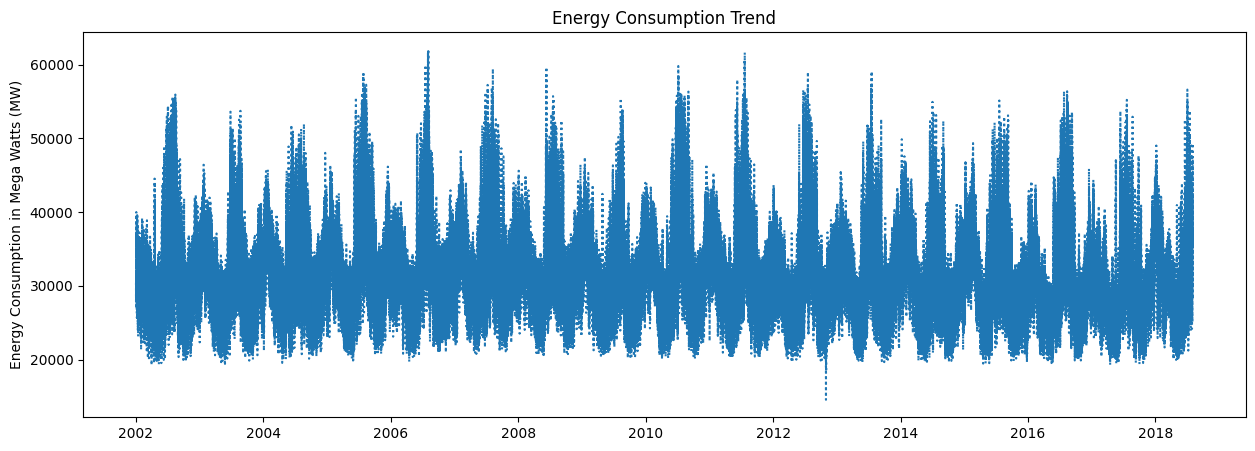

In [432]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(df, linestyle="dotted")
plt.ylabel("Energy Consumption in Mega Watts (MW)")
plt.title("Energy Consumption Trend");

#### Train / Test Split

In [433]:
df.index<"01-01-2015" # This gives an mask array of true and false

array([ True,  True,  True, ..., False, False, False], shape=(145366,))

In [434]:
df.loc[df.index<"01-01-2015"].tail()

,PJME_MW
Datetime,
2014-12-31 19:00:00,38906.0
2014-12-31 20:00:00,37772.0
2014-12-31 21:00:00,36602.0
2014-12-31 22:00:00,35326.0
2014-12-31 23:00:00,34003.0


In [435]:
train = df.loc[df.index<"01-01-2015"]
test = df.loc[df.index>="01-01-2015"]

In [436]:
len(train), len(test)

(113926, 31440)

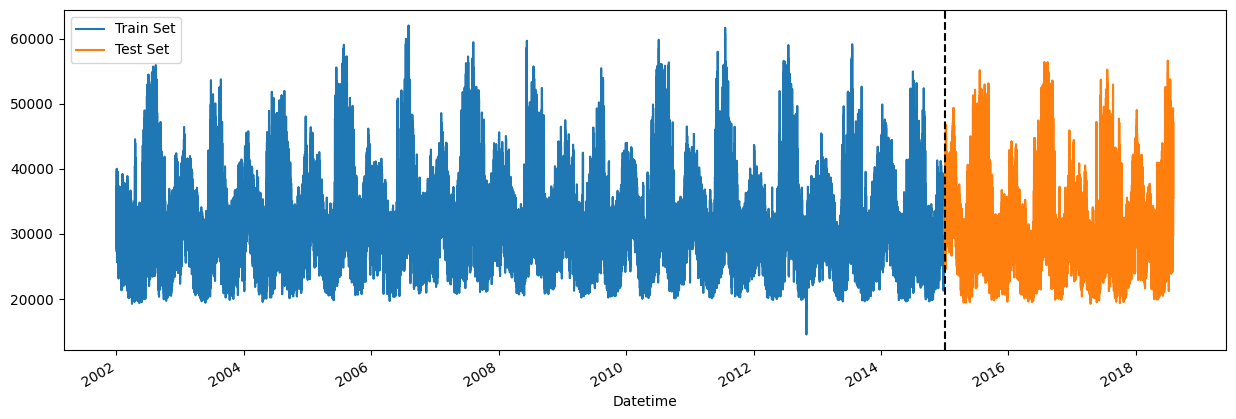

In [437]:
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax)
test.plot(ax=ax)
ax.axvline("2015-01-01", color="black", linestyle="--")
ax.legend(["Train Set", "Test Set"])
plt.show()

    Plotting 1 week of data

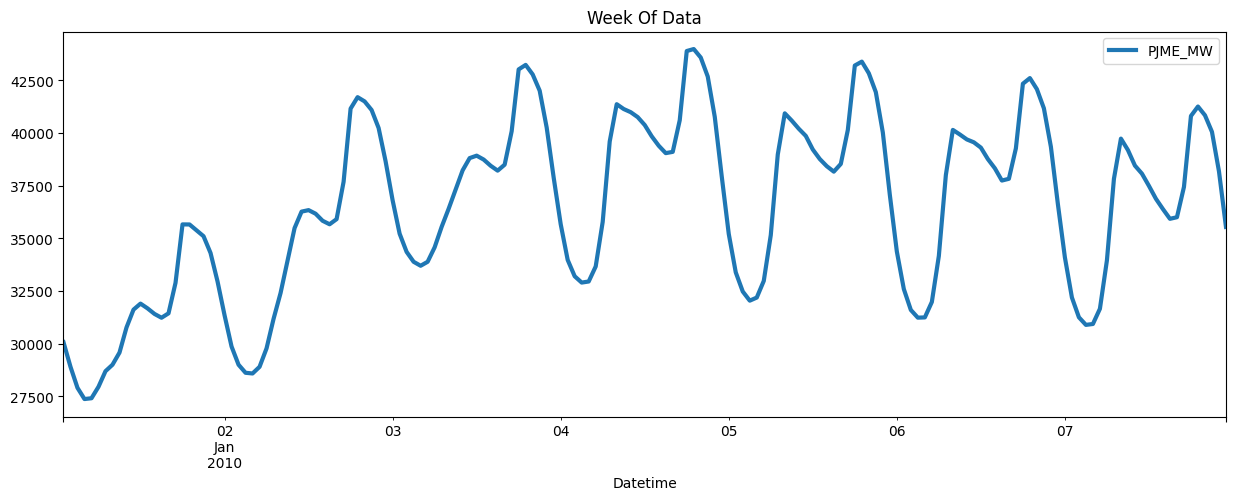

In [438]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data', linewidth="3")
plt.show()

#### Feature Engineering

##### Check features

In [439]:
df.index.hour

Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       ...
       15, 16, 17, 18, 19, 20, 21, 22, 23,  0],
      dtype='int32', name='Datetime', length=145366)

In [440]:
df.index.minute

Index([0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       ...
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype='int32', name='Datetime', length=145366)

In [441]:
df.index.day_of_week

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       3, 3, 3, 3, 3, 3, 3, 3, 3, 4],
      dtype='int32', name='Datetime', length=145366)

In [442]:
df.index.quarter

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
      dtype='int32', name='Datetime', length=145366)

In [443]:
df.index.month

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
      dtype='int32', name='Datetime', length=145366)

In [444]:
df.index.year

Index([2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002,
       ...
       2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018],
      dtype='int32', name='Datetime', length=145366)

In [445]:
df.index.isocalendar().week

Datetime
2002-01-01 01:00:00     1
2002-01-01 02:00:00     1
2002-01-01 03:00:00     1
2002-01-01 04:00:00     1
2002-01-01 05:00:00     1
                       ..
2018-08-02 20:00:00    31
2018-08-02 21:00:00    31
2018-08-02 22:00:00    31
2018-08-02 23:00:00    31
2018-08-03 00:00:00    31
Name: week, Length: 145366, dtype: UInt32

In [446]:
df.index.dayofyear

Index([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
       ...
       214, 214, 214, 214, 214, 214, 214, 214, 214, 215],
      dtype='int32', name='Datetime', length=145366)

##### Features

In [447]:
def create_features(df):
    """Create time series features based on time series index."""
    
    df = df.copy()
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.day_of_week
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["dayofyear"] = df.index.dayofyear
    return df


In [448]:
df = create_features(df)

#### Features to target relationship

Text(0.5, 1.0, 'MW by Hour')

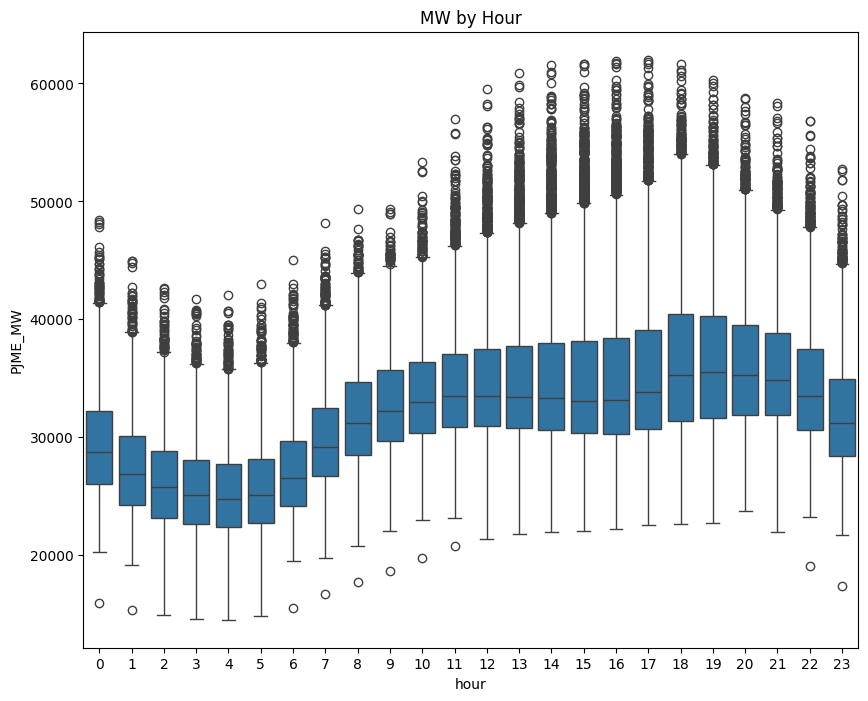

In [449]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title("MW by Hour")

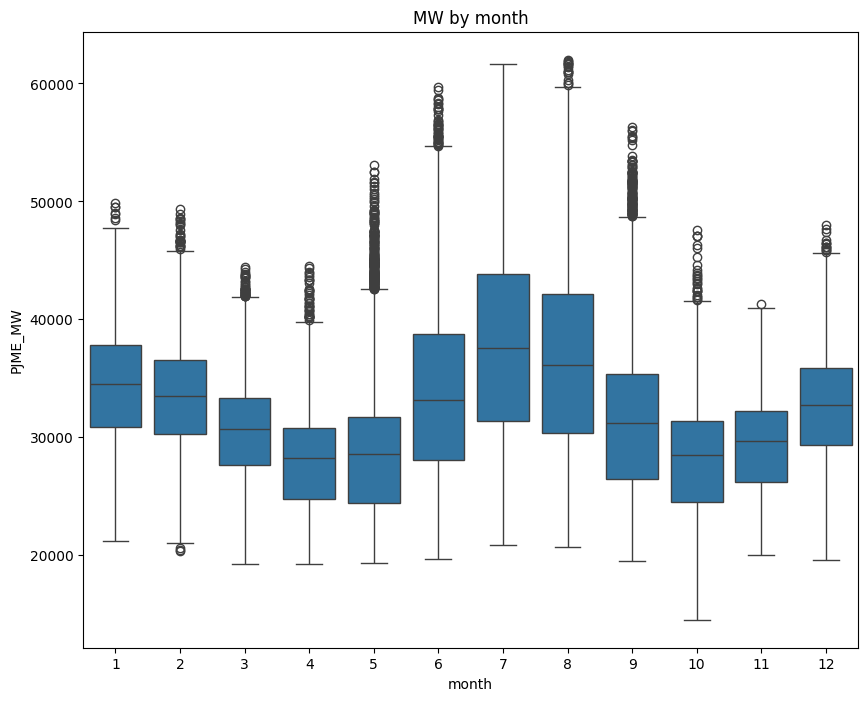

In [450]:
fig, ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x="month", y="PJME_MW")
ax.set_title("MW by month");

#### Create the model

In [451]:
train.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [452]:
train = create_features(train)
test = create_features(test)

In [453]:
train.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear'],
      dtype='str')

In [454]:
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year','dayofyear']
TARGET = 'PJME_MW'

In [455]:
train.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1


In [456]:
X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

In [457]:
reg = xgb.XGBRegressor(n_estimators=1000, 
                       early_stopping_rounds=50, 
                       learning_rate=0.01)
reg.fit(X_train, y_train, 
        eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100
        )
end_time = time.time()

[0]	validation_0-rmse:6407.35736	validation_1-rmse:6479.81619
[100]	validation_0-rmse:3911.97994	validation_1-rmse:4312.03224
[200]	validation_0-rmse:3244.38509	validation_1-rmse:3864.56545
[300]	validation_0-rmse:2996.08999	validation_1-rmse:3748.76687
[400]	validation_0-rmse:2830.28024	validation_1-rmse:3744.93340
[417]	validation_0-rmse:2801.66222	validation_1-rmse:3749.26089


#### Feature Importances

In [458]:
(reg.feature_importances_).shape

(6,)

In [459]:
np.array(X_train.columns).shape

(6,)

In [460]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': reg.feature_importances_
})


In [461]:
feature_importance

,feature,importance
0,hour,0.463878
1,dayofweek,0.162005
2,quarter,0.028881
3,month,0.203161
4,year,0.023824
5,dayofyear,0.118251


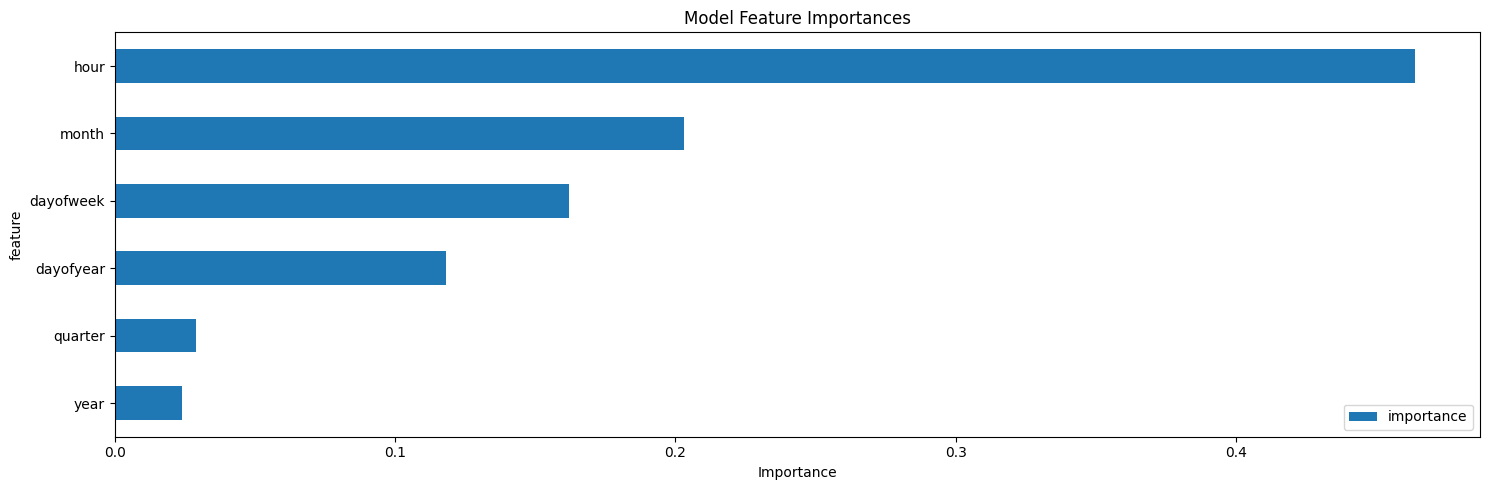

In [462]:
feature_importance.sort_values('importance', ascending=True).plot(
    kind='barh', figsize=(15, 5), x='feature', y='importance'
)
plt.title('Model Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


#### Forecast on test set

In [463]:
test["predictions"]=reg.predict(X_test)

In [464]:
# Check for duplicates in your main dataframe index
print(df.index.duplicated().sum())

# See which specific labels are repeated
print(df.index[df.index.duplicated()])

4
DatetimeIndex(['2014-11-02 02:00:00', '2015-11-01 02:00:00',
               '2016-11-06 02:00:00', '2017-11-05 02:00:00'],
              dtype='datetime64[us]', name='Datetime', freq=None)


In [465]:
df = df.merge(test['predictions'], how="left", left_index=True, right_index=True)
# df["predictions"] = test["predictions"] This will not work since we have duplicate index rows due to Daylight saving time.

In [466]:
df.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,predictions
Datetime,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,NaN


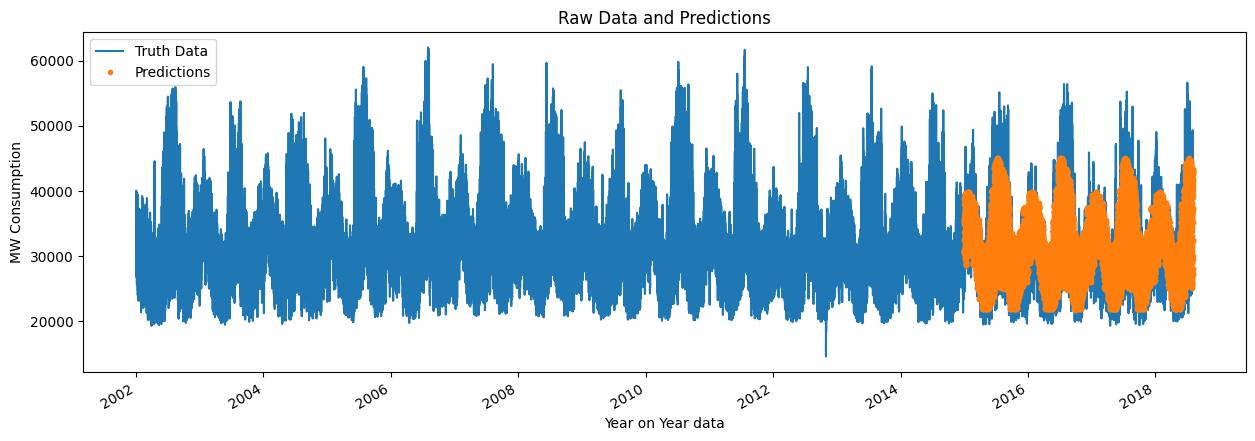

In [467]:
fig, ax = plt.subplots(figsize=(15,5))
df[['PJME_MW']].plot(ax=ax, legend=False)  # Use original ax, no legend here
df['predictions'].plot(ax=ax, style='.', legend=False)
plt.legend(['Truth Data', 'Predictions'])  # Add legend after both plots
ax.set_title('Raw Data and Predictions')
ax.set_xlabel("Year on Year data")
ax.set_ylabel("MW Consumption")
plt.show()


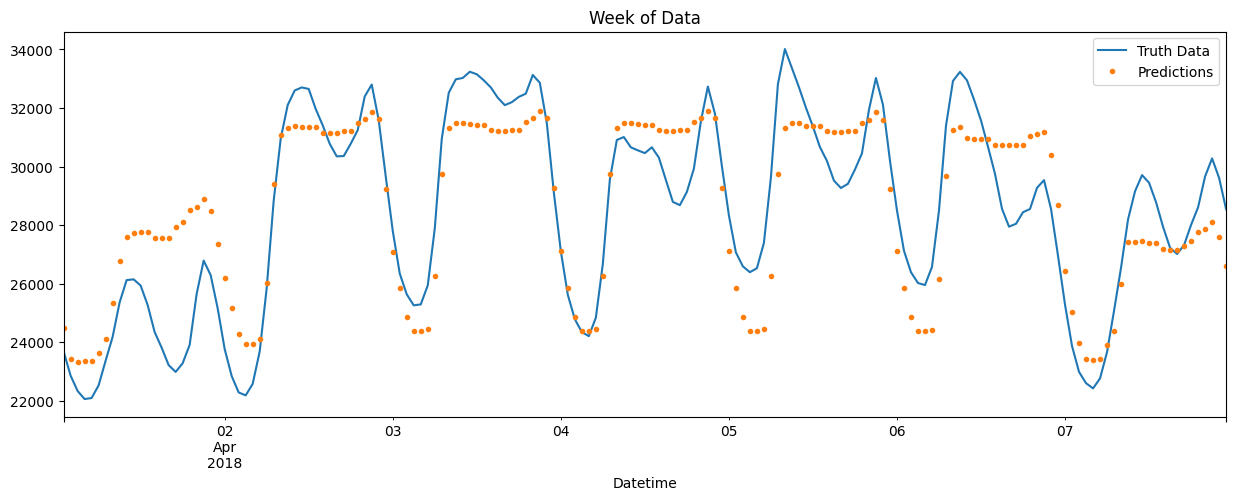

In [468]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]["PJME_MW"].plot(figsize=(15,5), title="Week of Data")
df.loc[(df.index>'04-01-2018') & (df.index < '04-08-2018')]["predictions"].plot(style=".")
plt.legend(["Truth Data", "Predictions"])
plt.show()

#### Model Evaluation

    Root mean squared error - Comparing truth and predicted values

In [469]:
test["baseline"] = test["PJME_MW"].mean()

In [470]:
score = np.sqrt(mean_squared_error(test["PJME_MW"], test["predictions"]))
print(f"RMSE Score on Test set for model: {score:0.4f}")

RMSE Score on Test set for model: 3741.0302


In [471]:
score = np.sqrt(mean_squared_error(test["PJME_MW"], test["baseline"]))
print(f"RMSE Score on Test set for baseline: {score:0.4f}")

RMSE Score on Test set for baseline: 6449.7023


    Model Vs Baseline performance

In [472]:
mean_absolute_error(test["PJME_MW"], test["predictions"])

2902.8865275375715

In [473]:
mean_absolute_error(test["PJME_MW"], test["baseline"])

5056.511060932736

    Calculate Error

In [474]:
test["error"]=np.abs(test[TARGET] - test['predictions'])

In [475]:
test["date"] = test.index.date

In [480]:
# test.groupby("date")["error"].mean().sort_values(ascending=False).head(10) This will work just fine
test.groupby(test.index.date)["error"].mean().sort_values(ascending=False).head(10)

2016-08-13    13829.866211
2016-08-14    13577.304362
2016-09-10    11235.855143
2016-09-09    11032.220215
2016-08-12    10667.820312
2018-01-06    10407.698161
2015-02-20    10143.611491
2017-05-19     9495.122640
2016-07-04     9440.610596
2016-07-23     9362.332682
Name: error, dtype: float64